## PUC-Rio
### Departamento de Engenharia Elétrica

### Lista de Exercícios - Echo State Network

Nesta lista de exercícios, iremos avaliar o uso de Echo State Network para previsão de séries temporais (ou identificação de sistemas).

Não esqueça que a ESN é **bastante** dependente da inicialização do modelo, visto que parte dos pesos **não** são aprendidos. Portanto, não esqueça de rodar uma quantidade razoável de vezes o modelo para cada item, de modo a ter uma avaliação mais confiável.

---
## Implementação da Echo State Network

Antes de responder os exercícios, implementamos a ESN do zero e definimos funções auxiliares de avaliação.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
class EchoStateNetwork:
    """
    Echo State Network (ESN) para identificação de sistemas e previsão de séries temporais.

    Arquitetura:
      - Camada de entrada:    pesos W_in (fixos, aleatórios)
      - Reservatório:         pesos W   (fixos, aleatórios esparsos)
      - Camada de saída:      pesos W_out (TREINADOS via regressão linear)

    Equações:
      x̃(t) = tanh(W_in · u(t) + W · x(t-1) + noise)
      x(t)  = (1 - α) · x(t-1)  +  α · x̃(t)       [leaking rate α]
      ŷ(t)  = W_out · [x(t); u(t)]
    """

    def __init__(
        self,
        n_reservoir: int   = 100,
        spectral_radius: float = 0.9,
        sparsity: float    = 0.1,
        leaking_rate: float = 1.0,
        input_scaling: float = 1.0,
        noise: float       = 1e-5,
        ridge: float       = 1e-6,
        seed: int          = None
    ):
        """
        Parâmetros
        ----------
        n_reservoir    : número de neurônios no reservatório
        spectral_radius: raio espectral da matriz W (controla estabilidade/memória)
        sparsity       : fração de conexões ATIVAS em W  (0 = densa, 1 = vazia)
        leaking_rate   : taxa de vazamento α ∈ (0, 1]; 1.0 = sem vazamento
        input_scaling  : escala dos pesos de entrada W_in
        noise          : ruído de regularização injetado no reservatório
        ridge          : parâmetro de regularização L2 para o readout
        seed           : semente aleatória para reprodutibilidade
        """
        self.n_reservoir     = n_reservoir
        self.spectral_radius = spectral_radius
        self.sparsity        = sparsity
        self.leaking_rate    = leaking_rate
        self.input_scaling   = input_scaling
        self.noise           = noise
        self.ridge           = ridge
        self.seed            = seed
        self.W_out           = None
        self.W               = None
        self.W_in            = None

    # ------------------------------------------------------------------
    # Inicialização dos pesos internos (fixos, não treinados)
    # ------------------------------------------------------------------
    def _init_weights(self, n_inputs: int) -> None:
        rng = np.random.RandomState(self.seed)

        # --- Pesos de entrada  [n_reservoir × n_inputs] ---
        self.W_in = rng.uniform(-1, 1, (self.n_reservoir, n_inputs)) * self.input_scaling

        # --- Pesos do reservatório  [n_reservoir × n_reservoir] ---
        # 1) Gera matriz densa aleatória
        W = rng.uniform(-1, 1, (self.n_reservoir, self.n_reservoir))
        # 2) Aplica esparsidade: zera (1 - sparsity) das conexões
        mask = rng.rand(*W.shape) > self.sparsity
        W[mask] = 0.0
        # 3) Escala para o raio espectral desejado
        eigenvalues = np.linalg.eigvals(W)
        current_sr  = np.max(np.abs(eigenvalues))
        if current_sr > 0:
            W *= self.spectral_radius / current_sr
        self.W = W

        # --- Bias do reservatório ---
        self.b_res = rng.uniform(-0.1, 0.1, self.n_reservoir)

    # ------------------------------------------------------------------
    # Propagação pelo reservatório
    # ------------------------------------------------------------------
    def _run_reservoir(self, X: np.ndarray, washout: int = 50) -> np.ndarray:
        """
        Executa o reservatório e retorna os estados após o washout.

        Parâmetros
        ----------
        X       : entrada [T × n_inputs]
        washout : número de passos iniciais descartados

        Retorna
        -------
        states  : estados do reservatório [(T - washout) × n_reservoir]
        """
        T = X.shape[0]
        x = np.zeros(self.n_reservoir)          # estado inicial
        states = np.zeros((T, self.n_reservoir))
        rng = np.random.RandomState(self.seed)

        for t in range(T):
            u       = X[t]
            pre_act = self.W_in @ u + self.W @ x + self.b_res
            pre_act += self.noise * rng.randn(self.n_reservoir)   # regularização
            x_new   = np.tanh(pre_act)
            # Leaking rate: interpolação entre estado anterior e novo
            x = (1.0 - self.leaking_rate) * x + self.leaking_rate * x_new
            states[t] = x

        return states[washout:]

    # ------------------------------------------------------------------
    # Treinamento (apenas W_out é ajustado)
    # ------------------------------------------------------------------
    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        washout: int = 50
    ) -> 'EchoStateNetwork':
        """
        Treina o readout W_out via Ridge Regression.

        Parâmetros
        ----------
        X       : entradas [T × n_inputs]  ou  [T] para SISO
        y       : saídas   [T × n_outputs] ou  [T] para SISO
        washout : passos iniciais descartados (transiente do reservatório)
        """
        if X.ndim == 1: X = X.reshape(-1, 1)
        if y.ndim == 1: y = y.reshape(-1, 1)

        self._init_weights(X.shape[1])
        self.washout_ = washout

        # Coleta estados do reservatório
        states   = self._run_reservoir(X, washout)         # [T-w × N_res]
        extended = np.hstack([states, X[washout:]])        # concatena entrada
        y_target = y[washout:]                             # alvo correspondente

        # Treinamento: regressão Ridge  (pseudo-inversa regularizada)
        reg = Ridge(alpha=self.ridge, fit_intercept=False)
        reg.fit(extended, y_target)
        self.W_out = reg.coef_                             # [n_outputs × n_ext]
        self._n_ext = extended.shape[1]
        return self

    # ------------------------------------------------------------------
    # Predição
    # ------------------------------------------------------------------
    def predict(self, X: np.ndarray, washout: int = 0) -> np.ndarray:
        """
        Gera predições para novas entradas.

        Parâmetros
        ----------
        X       : entradas de teste
        washout : washout adicional no teste (normalmente 0)
        """
        if X.ndim == 1: X = X.reshape(-1, 1)
        states   = self._run_reservoir(X, washout)
        extended = np.hstack([states, X[washout:]])
        return (extended @ self.W_out.T).squeeze()


# ------------------------------------------------------------------
# Funções utilitárias
# ------------------------------------------------------------------

def rmse(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def avaliar_esn(esn, u_train, y_train, u_test, y_test, washout=50, titulo=''):
    """
    Treina e avalia uma ESN, retornando métricas e plotando resultado.
    """
    esn.fit(u_train, y_train, washout=washout)
    y_pred = esn.predict(u_test)
    erro   = rmse(y_test, y_pred)

    plt.figure(figsize=(12, 3))
    plt.plot(y_test, label='Real', linewidth=1.5)
    plt.plot(y_pred, label='ESN',  linewidth=1.5, linestyle='--')
    plt.title(f'{titulo}  —  RMSE = {erro:.5f}')
    plt.xlabel('Tempo (amostras)')
    plt.ylabel('Saída')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return erro


def avaliar_multiplas_sementes(config, u_train, y_train, u_test, y_test,
                                washout=50, n_runs=15):
    """
    Roda a ESN com `n_runs` sementes diferentes para estimar
    a variabilidade da inicialização aleatória.

    Retorna array de RMSEs.
    """
    erros = []
    for seed in range(n_runs):
        esn = EchoStateNetwork(**config, seed=seed)
        esn.fit(u_train, y_train, washout=washout)
        y_pred = esn.predict(u_test)
        erros.append(rmse(y_test, y_pred))
    erros = np.array(erros)
    print(f"  RMSE médio: {erros.mean():.5f}  |  std: {erros.std():.5f}"
          f"  |  min: {erros.min():.5f}  |  max: {erros.max():.5f}")
    return erros


print("✅ Implementação da ESN carregada com sucesso!")

✅ Implementação da ESN carregada com sucesso!


---
## Exercício 1 — Base de dados e análise exploratória

Escolha uma base de dados presente em https://homes.esat.kuleuven.be/~smc/daisy/daisydata.html ou no repositório. Faça um gráfico de todas as variáveis do problema para avaliar a dinâmica de cada uma delas.

**OBS: Este é apenas um **exemplo**. Não use de fato o que está aqui abaixo. :-)**

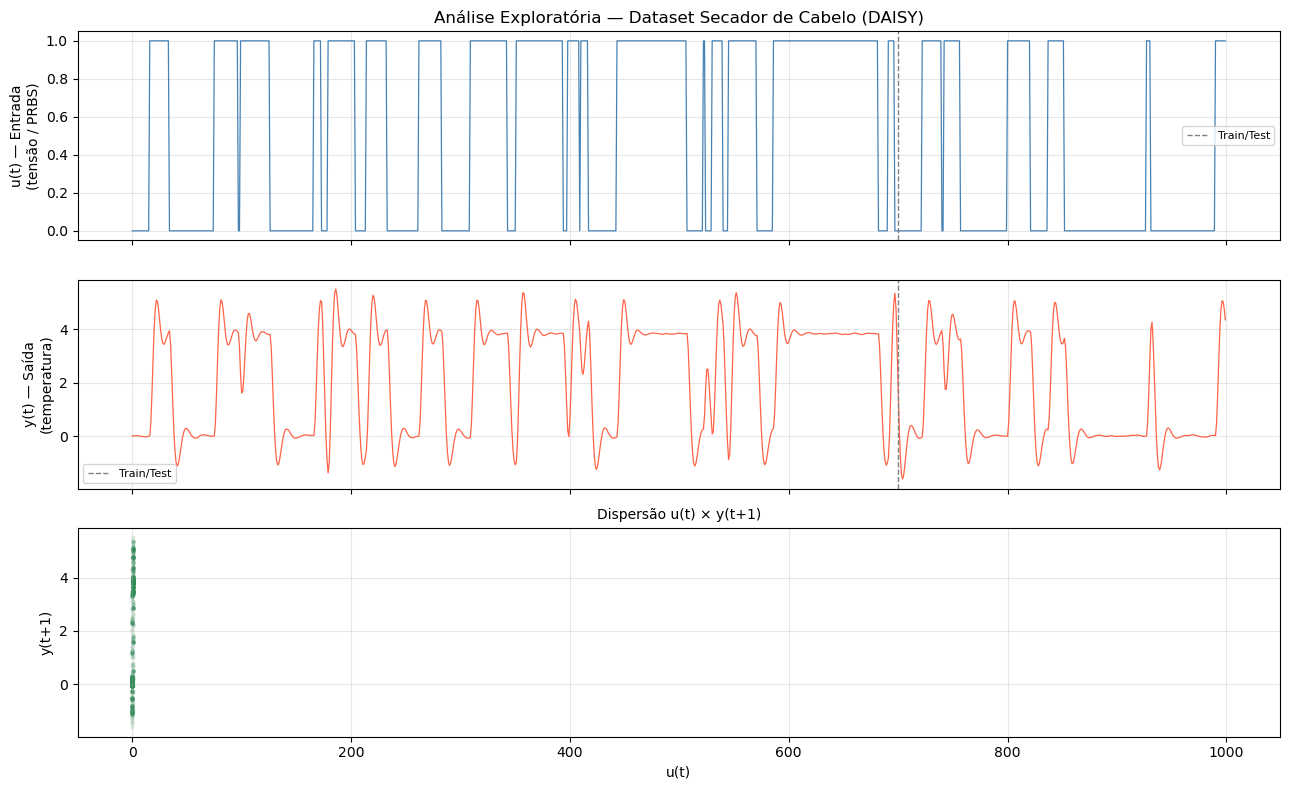

Treino: 700 amostras  |  Teste: 300 amostras
u — média: 0.521, std: 0.500
y — média: 2.005, std: 2.026


In [3]:
def gerar_dataset_secador(N=1000, seed=0):
    """
    Simula o sistema do secador de cabelo (DAISY - hair dryer).

    Dinâmica não-linear discreta:
        y(t) = b1*u(t-1) + b2*u(t-2)
               - a1*y(t-1) - a2*y(t-2)
               + 0.05 * sin(y(t-1))   ← não-linearidade leve
               + ε

    A entrada é um sinal PRBS (Pseudo-Random Binary Sequence),
    típico em experimentos de identificação de sistemas.
    """
    rng  = np.random.RandomState(seed)
    a1, a2 = -1.5, 0.7          # pólos do sistema
    b1, b2 =  0.5, 0.3          # zeros do sistema

    # Entrada PRBS (Binary: alterna entre 0 e 1 em instantes aleatórios)
    u = np.zeros(N)
    val = 0
    for t in range(N):
        if rng.rand() < 0.05:     # 5% de chance de mudar de nível
            val = 1 - val
        u[t] = val

    y   = np.zeros(N)
    eps = 0.005 * rng.randn(N)   # ruído de medição

    for t in range(2, N):
        y[t] = (b1*u[t-1] + b2*u[t-2]
                - a1*y[t-1] - a2*y[t-2]
                + 0.05*np.sin(y[t-1])
                + eps[t])
    return u, y


# Gera os dados
N_TOTAL  = 1000
N_TRAIN  = 700
WASHOUT  = 50

u_all, y_all = gerar_dataset_secador(N=N_TOTAL, seed=0)

u_train, y_train = u_all[:N_TRAIN],  y_all[:N_TRAIN]
u_test,  y_test  = u_all[N_TRAIN:],  y_all[N_TRAIN:]

# ──────────────────────────────────────────────
# Visualização exploratória (Exercício 1)
# ──────────────────────────────────────────────
t = np.arange(N_TOTAL)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

# Entrada
axes[0].plot(t, u_all, color='steelblue', linewidth=0.9)
axes[0].set_ylabel('u(t) — Entrada\n(tensão / PRBS)', fontsize=10)
axes[0].set_title('Análise Exploratória — Dataset Secador de Cabelo (DAISY)', fontsize=12)

# Saída
axes[1].plot(t, y_all, color='tomato', linewidth=0.9)
axes[1].set_ylabel('y(t) — Saída\n(temperatura)', fontsize=10)

# Diagrama de dispersão u × y para evidenciar a relação entrada-saída
axes[2].scatter(u_all[:-1], y_all[1:], alpha=0.1, s=5, color='seagreen')
axes[2].set_xlabel('u(t)')
axes[2].set_ylabel('y(t+1)', fontsize=10)
axes[2].set_title('Dispersão u(t) × y(t+1)', fontsize=10)

for ax in axes[:2]:
    ax.axvline(N_TRAIN, color='gray', linestyle='--', linewidth=1, label='Train/Test')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Treino: {N_TRAIN} amostras  |  Teste: {N_TOTAL - N_TRAIN} amostras")
print(f"u — média: {u_all.mean():.3f}, std: {u_all.std():.3f}")
print(f"y — média: {y_all.mean():.3f}, std: {y_all.std():.3f}")

---
## Exercício 2 — Configuração inicial de hiperparâmetros

Rode o modelo ESN com uma configuração inicial de hiperparâmetros. Justifique a escolha de cada uma delas.

  Configuração Base — avaliação com 15 sementes
  RMSE médio: 1.34251  |  std: 0.68955  |  min: 0.30486  |  max: 2.92703


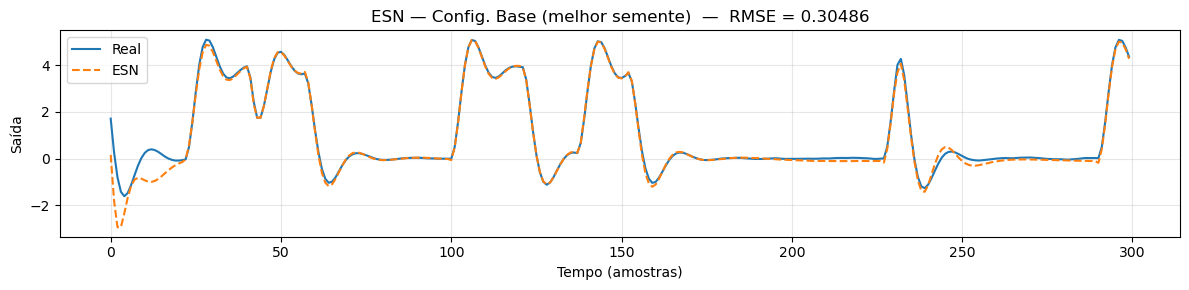

In [4]:
# ──────────────────────────────────────────────────────────────────────
#  Configuração base — justificativas embutidas nos comentários
# ──────────────────────────────────────────────────────────────────────
config_base = dict(
    n_reservoir    = 100,   # 100 neurônios: bom ponto de partida para séries de ~1000 amostras
    spectral_radius= 0.9,   # < 1 garante Echo State Property (ESP); próximo de 1 → memória longa
    sparsity       = 0.1,   # 10% de conexões ativas: reservatório esparso, típico na literatura
    leaking_rate   = 0.5,   # α = 0.5 integra estados passado e novo; útil para dinâmica suave
    input_scaling  = 1.0,   # escala neutra — ajustar se a entrada tiver amplitude muito diferente
    noise          = 1e-5,  # ruído pequeno para regularização interna
    ridge          = 1e-6,  # regularização L2 no readout: evita overfitting
)

print("=" * 55)
print("  Configuração Base — avaliação com 15 sementes")
print("=" * 55)
erros_base = avaliar_multiplas_sementes(
    config_base, u_train, y_train, u_test, y_test, washout=WASHOUT, n_runs=15
)

# Melhor semente — plot final
melhor_seed = int(np.argmin(erros_base))
esn_base = EchoStateNetwork(**config_base, seed=melhor_seed)
_ = avaliar_esn(esn_base, u_train, y_train, u_test, y_test,
                washout=WASHOUT, titulo='ESN — Config. Base (melhor semente)')

---
## Exercício 3 — Tamanho do reservatório

Modifique o tamanho do reservatório e avalie o resultado dessa mudança. De que forma a alteração dos pesos pode impactar no resultado final?


── n_reservoir = 10 ──
  RMSE médio: 0.94978  |  std: 1.10628  |  min: 0.23312  |  max: 4.19585

── n_reservoir = 50 ──
  RMSE médio: 0.73958  |  std: 0.45828  |  min: 0.12853  |  max: 1.73952

── n_reservoir = 100 ──
  RMSE médio: 1.34251  |  std: 0.68955  |  min: 0.30486  |  max: 2.92703

── n_reservoir = 200 ──
  RMSE médio: 1.44630  |  std: 0.70258  |  min: 0.44143  |  max: 2.46488

── n_reservoir = 500 ──
  RMSE médio: 1.19486  |  std: 0.67461  |  min: 0.33564  |  max: 3.08882


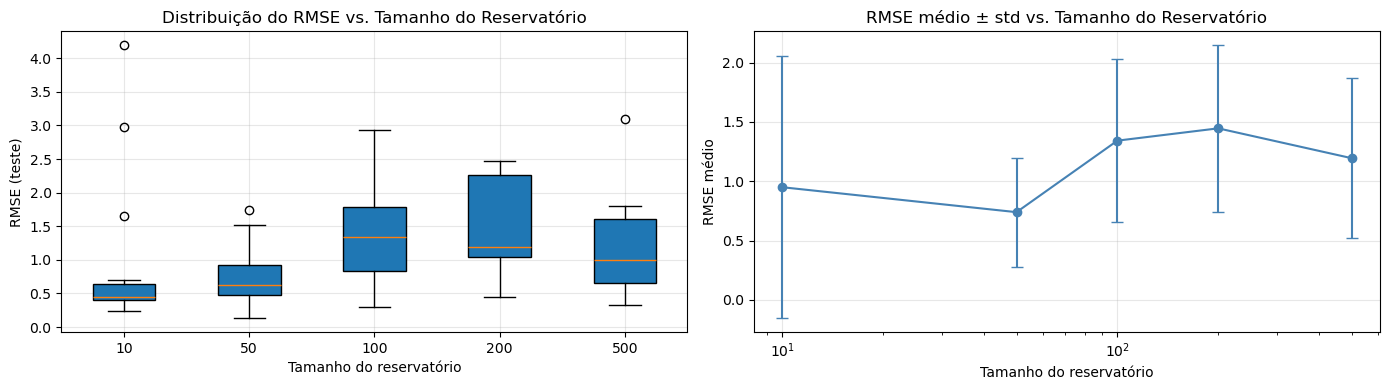

In [5]:
tamanhos = [10, 50, 100, 200, 500]
n_runs   = 15

resultados_tamanho = {}

for N_res in tamanhos:
    config = {**config_base, 'n_reservoir': N_res}
    print(f"\n── n_reservoir = {N_res} ──")
    erros = avaliar_multiplas_sementes(
        config, u_train, y_train, u_test, y_test, washout=WASHOUT, n_runs=n_runs
    )
    resultados_tamanho[N_res] = erros

# ─── Boxplot comparativo ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

medias = [resultados_tamanho[n].mean() for n in tamanhos]
stds   = [resultados_tamanho[n].std()  for n in tamanhos]

axes[0].boxplot([resultados_tamanho[n] for n in tamanhos],
                labels=[str(n) for n in tamanhos], patch_artist=True)
axes[0].set_xlabel('Tamanho do reservatório')
axes[0].set_ylabel('RMSE (teste)')
axes[0].set_title('Distribuição do RMSE vs. Tamanho do Reservatório')

axes[1].errorbar(tamanhos, medias, yerr=stds, marker='o', capsize=4, color='steelblue')
axes[1].set_xlabel('Tamanho do reservatório')
axes[1].set_ylabel('RMSE médio')
axes[1].set_title('RMSE médio ± std vs. Tamanho do Reservatório')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

---
## Exercício 4 — Leaking Rate

Modifique o parâmetro de **leaking rate** e avalie o resultado dessa mudança.


── leaking_rate = 0.1 ──
  RMSE médio: 12.64620  |  std: 5.68286  |  min: 5.98347  |  max: 24.97400

── leaking_rate = 0.3 ──
  RMSE médio: 1.66271  |  std: 0.75689  |  min: 0.32525  |  max: 2.72568

── leaking_rate = 0.5 ──
  RMSE médio: 1.34251  |  std: 0.68955  |  min: 0.30486  |  max: 2.92703

── leaking_rate = 0.7 ──
  RMSE médio: 0.94952  |  std: 0.60377  |  min: 0.27657  |  max: 2.01940

── leaking_rate = 1.0 ──
  RMSE médio: 0.96842  |  std: 0.55397  |  min: 0.35420  |  max: 2.04623


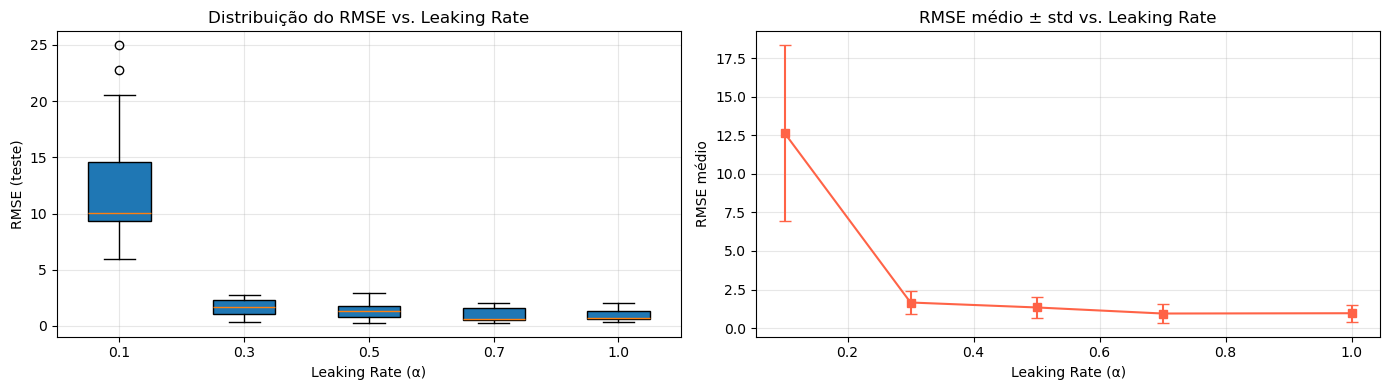

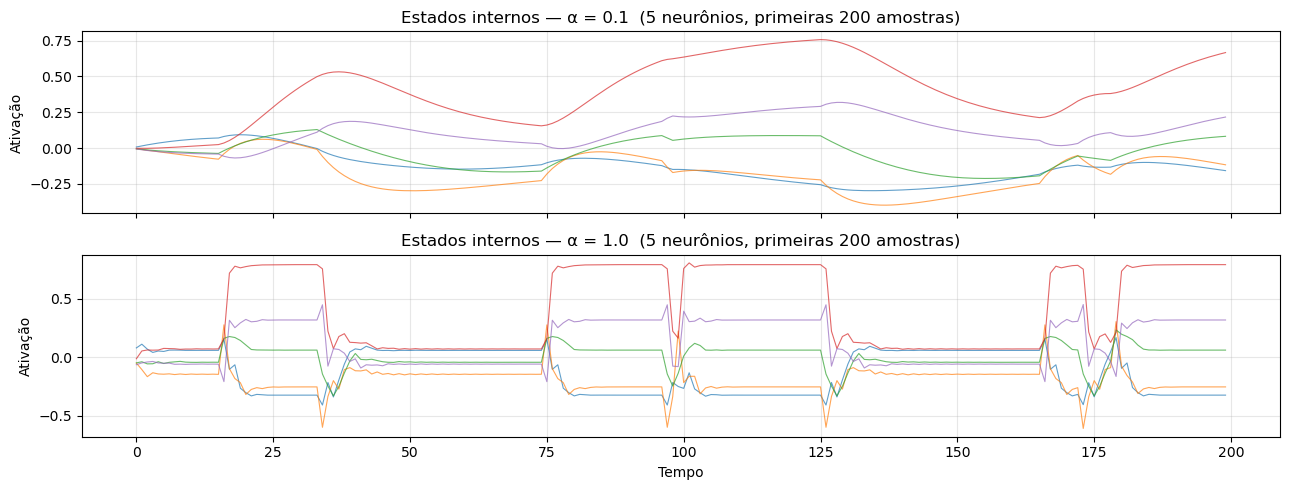

In [6]:
leaking_rates = [0.1, 0.3, 0.5, 0.7, 1.0]
resultados_lr = {}

for lr in leaking_rates:
    config = {**config_base, 'leaking_rate': lr}
    print(f"\n── leaking_rate = {lr} ──")
    erros = avaliar_multiplas_sementes(
        config, u_train, y_train, u_test, y_test, washout=WASHOUT, n_runs=n_runs
    )
    resultados_lr[lr] = erros

# ─── Plots ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

medias = [resultados_lr[lr].mean() for lr in leaking_rates]
stds   = [resultados_lr[lr].std()  for lr in leaking_rates]

axes[0].boxplot([resultados_lr[lr] for lr in leaking_rates],
                labels=[str(lr) for lr in leaking_rates], patch_artist=True)
axes[0].set_xlabel('Leaking Rate (α)')
axes[0].set_ylabel('RMSE (teste)')
axes[0].set_title('Distribuição do RMSE vs. Leaking Rate')

axes[1].errorbar(leaking_rates, medias, yerr=stds, marker='s', capsize=4, color='tomato')
axes[1].set_xlabel('Leaking Rate (α)')
axes[1].set_ylabel('RMSE médio')
axes[1].set_title('RMSE médio ± std vs. Leaking Rate')

plt.tight_layout()
plt.show()

# Visualiza a dinâmica interna para α = 0.1 vs α = 1.0
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
for i, lr in enumerate([0.1, 1.0]):
    esn_tmp = EchoStateNetwork(**{**config_base, 'leaking_rate': lr}, seed=0)
    esn_tmp._init_weights(1)
    estados = esn_tmp._run_reservoir(u_train.reshape(-1, 1), washout=0)
    axes[i].plot(estados[:200, :5], alpha=0.7, linewidth=0.8)  # primeiros 5 neurônios
    axes[i].set_title(f'Estados internos — α = {lr}  (5 neurônios, primeiras 200 amostras)')
    axes[i].set_ylabel('Ativação')
axes[1].set_xlabel('Tempo')
plt.tight_layout()
plt.show()

---
## Exercício 5 — Esparsidade

Modifique o parâmetro de **esparsidade** e avalie o resultado dessa mudança.


── sparsity = 0.01  (1% de conexões ativas) ──
  RMSE médio: 3.48857  |  std: 3.93077  |  min: 0.56534  |  max: 15.21971

── sparsity = 0.05  (5% de conexões ativas) ──
  RMSE médio: 0.75094  |  std: 0.46373  |  min: 0.26071  |  max: 1.69695

── sparsity = 0.1  (10% de conexões ativas) ──
  RMSE médio: 1.34251  |  std: 0.68955  |  min: 0.30486  |  max: 2.92703

── sparsity = 0.2  (20% de conexões ativas) ──
  RMSE médio: 0.71190  |  std: 0.35069  |  min: 0.32700  |  max: 1.67182

── sparsity = 0.5  (50% de conexões ativas) ──
  RMSE médio: 1.05450  |  std: 0.75448  |  min: 0.18817  |  max: 3.21794

── sparsity = 0.9  (90% de conexões ativas) ──
  RMSE médio: 0.85067  |  std: 0.42060  |  min: 0.30482  |  max: 1.68663


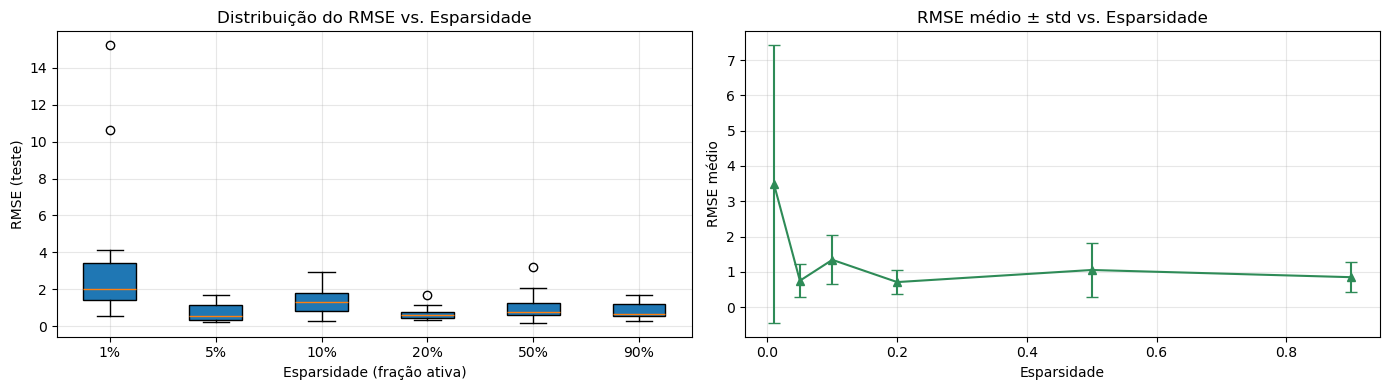

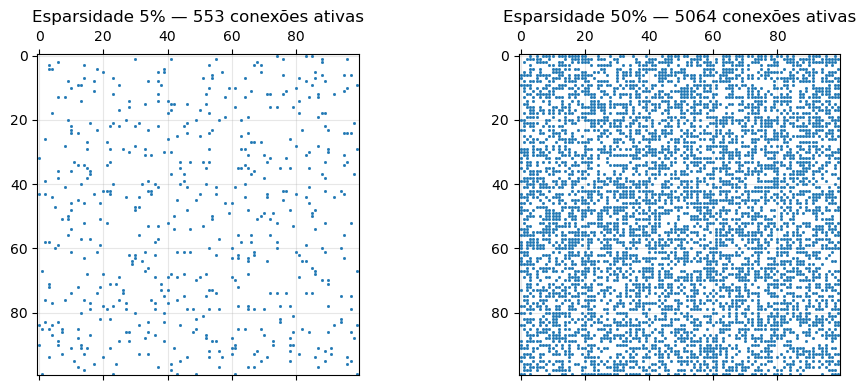

In [7]:
esparsidades = [0.01, 0.05, 0.10, 0.20, 0.50, 0.90]
resultados_esp = {}

for esp in esparsidades:
    config = {**config_base, 'sparsity': esp}
    print(f"\n── sparsity = {esp}  ({esp*100:.0f}% de conexões ativas) ──")
    erros = avaliar_multiplas_sementes(
        config, u_train, y_train, u_test, y_test, washout=WASHOUT, n_runs=n_runs
    )
    resultados_esp[esp] = erros

# ─── Plots ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

medias = [resultados_esp[e].mean() for e in esparsidades]
stds   = [resultados_esp[e].std()  for e in esparsidades]

axes[0].boxplot([resultados_esp[e] for e in esparsidades],
                labels=[f'{e:.0%}' for e in esparsidades], patch_artist=True)
axes[0].set_xlabel('Esparsidade (fração ativa)')
axes[0].set_ylabel('RMSE (teste)')
axes[0].set_title('Distribuição do RMSE vs. Esparsidade')

axes[1].errorbar(esparsidades, medias, yerr=stds, marker='^', capsize=4, color='seagreen')
axes[1].set_xlabel('Esparsidade')
axes[1].set_ylabel('RMSE médio')
axes[1].set_title('RMSE médio ± std vs. Esparsidade')

plt.tight_layout()
plt.show()

# Visualiza estrutura da matriz W para dois extremos
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, esp in zip(axes, [0.05, 0.50]):
    esn_tmp = EchoStateNetwork(**{**config_base, 'sparsity': esp}, seed=0)
    esn_tmp._init_weights(1)
    ax.spy(esn_tmp.W, markersize=1)
    n_conn = np.sum(esn_tmp.W != 0)
    ax.set_title(f'Esparsidade {esp:.0%} — {n_conn} conexões ativas')
plt.tight_layout()
plt.show()

---
## Exercício 6 — Tempo de washout

Modifique o parâmetro de **tempo de washout** e avalie o resultado dessa mudança.


── washout = 0 amostras ──
  RMSE médio: 0.23660  |  std: 0.02780  |  min: 0.21320  |  max: 0.32894

── washout = 10 amostras ──
  RMSE médio: 1.00479  |  std: 0.57647  |  min: 0.20476  |  max: 2.09293

── washout = 25 amostras ──
  RMSE médio: 1.24908  |  std: 0.60854  |  min: 0.45293  |  max: 2.45752

── washout = 50 amostras ──
  RMSE médio: 1.34251  |  std: 0.68955  |  min: 0.30486  |  max: 2.92703

── washout = 100 amostras ──
  RMSE médio: 1.40606  |  std: 0.72672  |  min: 0.30838  |  max: 3.06912

── washout = 200 amostras ──
  RMSE médio: 1.24775  |  std: 0.59708  |  min: 0.44626  |  max: 2.73689


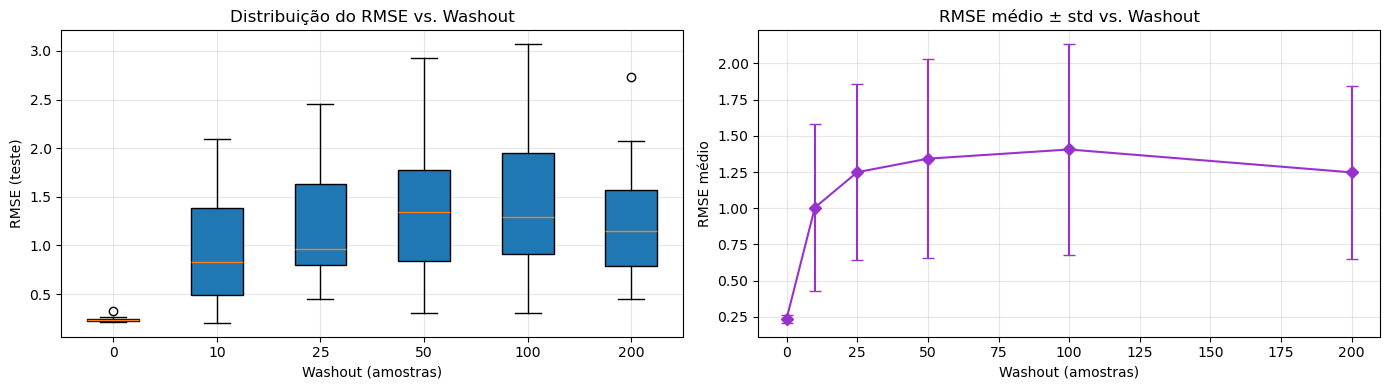

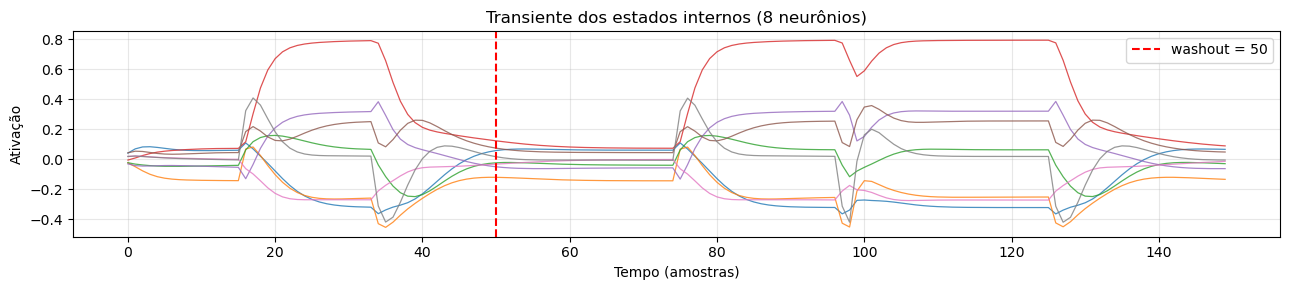

In [8]:
washouts = [0, 10, 25, 50, 100, 200]
resultados_wash = {}

for ws in washouts:
    config = config_base.copy()
    print(f"\n── washout = {ws} amostras ──")
    erros = avaliar_multiplas_sementes(
        config, u_train, y_train, u_test, y_test, washout=ws, n_runs=n_runs
    )
    resultados_wash[ws] = erros

# ─── Plots ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

medias = [resultados_wash[ws].mean() for ws in washouts]
stds   = [resultados_wash[ws].std()  for ws in washouts]

axes[0].boxplot([resultados_wash[ws] for ws in washouts],
                labels=[str(ws) for ws in washouts], patch_artist=True)
axes[0].set_xlabel('Washout (amostras)')
axes[0].set_ylabel('RMSE (teste)')
axes[0].set_title('Distribuição do RMSE vs. Washout')

axes[1].errorbar(washouts, medias, yerr=stds, marker='D', capsize=4, color='darkorchid')
axes[1].set_xlabel('Washout (amostras)')
axes[1].set_ylabel('RMSE médio')
axes[1].set_title('RMSE médio ± std vs. Washout')

plt.tight_layout()
plt.show()

# Mostra o transiente dos estados internos (por que o washout importa)
esn_tmp = EchoStateNetwork(**config_base, seed=0)
esn_tmp._init_weights(1)
estados = esn_tmp._run_reservoir(u_train.reshape(-1, 1), washout=0)

plt.figure(figsize=(13, 3))
plt.plot(estados[:150, :8], alpha=0.8, linewidth=0.9)
plt.axvline(50, color='red', linestyle='--', linewidth=1.5, label='washout = 50')
plt.title('Transiente dos estados internos (8 neurônios)')
plt.xlabel('Tempo (amostras)')
plt.ylabel('Ativação')
plt.legend()
plt.tight_layout()
plt.show()